<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/dnanf_tube_count_launch_power_comparison_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNANF tube 개수에 따른 launch power–throughput 비교

이 Colab은 기존 `dnanf_fig2_hcf_colab.ipynb`의 200 km HCF 링크를 확장해,
**double-nested antiresonant tube 개수 (n=2,4,6,8,10)**에 따른
launch power–C-band throughput을 비교합니다. 원 노트북의 **5-tube DNANF**도
회색 점선 기준선으로 함께 표시합니다.

채널별 계산식은 원 노트북과 같습니다.

$$
\mathrm{SNR}_i=\frac{P_i}{P_{\mathrm{ASE},i}+\eta_iP_i^3+P_{\mathrm{IMI},i}+P_{\mathrm{TRX},i}},
\qquad T_{\rm tot}=\sum_i2R_s\log_2(1+\mathrm{SNR}_i).
$$

## 먼저 알아야 할 한계

- 기존 코드처럼 **각 tube 개수를 동일한 손실·분산 기준값에 매번 재보정**하면 tube-count 효과가 제거되어 곡선이 겹칩니다.
- 여기서는 5-tube를 논문의 (D(1310)=2.17), (D(1550)=3.20\ \mathrm{ps/(nm\,km)})에 한 번만 보정하고,
  Hasan 경험식이 예측하는 tube-count별 (f_2)의 **상대 변화만 보존**합니다.
- 비교의 공정성을 위해 기본 실행에서는 모든 경우에 동일한 손실, 비선형계수 γ, IMI를 사용합니다. 즉, 기본 결과는 **분산 → GN-NLI → 최적 launch power** 경로만 보는 민감도 분석입니다.
- Hasan 경험식의 tube-count 검증 범위는 주로 (n=6\sim12)입니다. 따라서 (n=2)는 물리적으로 폐쇄된 tube ring을 만들 수 없는 수학적 외삽이며, (n=4)도 경험식 범위 밖입니다.


In [1]:
%pip -q install numpy scipy pandas matplotlib


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

try:
    from IPython.display import display
except ImportError:
    display = print

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
U01 = 2.4048255577
DB_PER_NEPER = 10.0 / np.log(10.0)

REQUESTED_TUBE_COUNTS = (2, 4, 6, 8, 10)
REFERENCE_TUBE_COUNT = 5
ALL_TUBE_COUNTS = (2, 4, 5, 6, 8, 10)


@dataclass(frozen=True)
class ReferenceDNANF:
    '''5-tube geometry used by the original Fig. 2 reconstruction.'''

    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self) -> float:
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


@dataclass(frozen=True)
class HCFLink:
    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    span_length_km: float = 200.0
    n_spans: int = 1
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0
    nonlinear_coefficient_per_w_km: float = 5e-4
    imi_coefficient_db_per_km: float = -52.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9

    @property
    def total_length_km(self) -> float:
        return self.n_spans * self.span_length_km


REFERENCE_GEOMETRY = ReferenceDNANF()
LINK = HCFLink()
FIXED_GAP_M = REFERENCE_GEOMETRY.perimeter_gap_m


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def outer_tube_diameter_um(tube_count: int) -> float:
    '''Diameter required to keep R and perimeter gap g fixed.'''
    theta = np.pi / tube_count
    denominator = 1.0 - np.sin(theta)
    if abs(denominator) < 1e-12:
        return np.nan
    diameter_m = (
        2.0 * REFERENCE_GEOMETRY.core_radius_m * np.sin(theta) - FIXED_GAP_M
    ) / denominator
    return float(diameter_m * 1e6)


def raw_hasan_coefficients(tube_count: int) -> tuple[float, float]:
    '''Hasan et al. empirical effective-radius coefficients.'''
    radius_to_gap = REFERENCE_GEOMETRY.core_radius_m / FIXED_GAP_M
    nested_elements = REFERENCE_GEOMETRY.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * tube_count * np.exp(b0 / radius_to_gap)
        - b2 * tube_count
        + b3
        + 0.0045 * np.exp(-4.1589 / (nested_elements * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_index(
    wavelength_m: np.ndarray, f1: float, f2: float
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = REFERENCE_GEOMETRY.core_radius_m
    wall = REFERENCE_GEOMETRY.membrane_thickness_m
    effective_radius = f1 * radius * (
        1.0 - f2 * wavelength_m**2 / (radius * wall)
    )
    return 1.0 - 0.125 * (
        U01 * wavelength_m / (np.pi * effective_radius)
    ) ** 2


def chromatic_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def neff(offset: float) -> np.ndarray:
        return effective_index(wavelength_m + offset, f1, f2)

    second_derivative = (
        -neff(2.0 * step)
        + 16.0 * neff(step)
        - 30.0 * neff(0.0)
        + 16.0 * neff(-step)
        - neff(-2.0 * step)
    ) / (12.0 * step**2)
    dispersion_si = -(wavelength_m / C0) * second_derivative
    return dispersion_si / 1e-6


def calibrate_reference_five_tube() -> tuple[float, float]:
    '''Calibrate only N=5 to the two values used in the original notebook.'''
    reference_nm = np.array([1310.0, 1550.0])
    target_dispersion = np.array([2.17, 3.20])
    initial = np.array(raw_hasan_coefficients(REFERENCE_TUBE_COUNT))

    def residual(parameters: np.ndarray) -> np.ndarray:
        calculated = chromatic_dispersion_ps_nm_km(
            reference_nm * 1e-9, parameters[0], parameters[1]
        )
        return calculated - target_dispersion

    fit = least_squares(
        residual,
        x0=initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac",
        diff_step=1e-3,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
    )
    if not fit.success or np.max(np.abs(fit.fun)) > 1e-3:
        raise RuntimeError(f"Reference dispersion calibration failed: {fit.fun}")
    return float(fit.x[0]), float(fit.x[1])


F1_REF_CAL, F2_REF_CAL = calibrate_reference_five_tube()
F1_REF_RAW, F2_REF_RAW = raw_hasan_coefficients(REFERENCE_TUBE_COUNT)


def anchored_coefficients(tube_count: int) -> tuple[float, float]:
    '''Keep the calibrated N=5 anchor and preserve Hasan's relative N trend.'''
    f1_raw, f2_raw = raw_hasan_coefficients(tube_count)
    f1 = F1_REF_CAL + (f1_raw - F1_REF_RAW)
    f2 = F2_REF_CAL + (f2_raw - F2_REF_RAW)
    return float(f1), float(f2)


def capillary_bouncing_ray_loss_db_km(wavelength_m: np.ndarray) -> np.ndarray:
    '''Original notebook's thin-wall capillary leakage basis (no explicit N dependence).'''
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = REFERENCE_GEOMETRY.core_radius_m
    wall = REFERENCE_GEOMETRY.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denominator = 4.0 * np.cos(phase) ** 2 + (
        kappa / sigma + sigma / kappa
    ) ** 2 * np.sin(phase) ** 2
    tm_denominator = 4.0 * np.cos(phase) ** 2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    ) ** 2 * np.sin(phase) ** 2
    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    return 0.5 * (alpha_te_per_m + alpha_tm_per_m) * DB_PER_NEPER * 1000.0


def baseline_attenuation_db_km(wavelength_m: np.ndarray) -> np.ndarray:
    '''Original 5-tube attenuation curve anchored at 1550 and 1310 nm.'''
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])
    lambda_ref_m = reference_nm[0] * 1e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9)
    basis_reference = np.column_stack(
        [
            (lambda_ref_m / (reference_nm * 1e-9)) ** 3,
            (br_ref / br_ref[0]) ** 2,
        ]
    )
    a_surface, a_nested = np.linalg.solve(basis_reference, reference_alpha)
    if a_surface < 0.0 or a_nested < 0.0:
        raise RuntimeError("Calibrated attenuation terms must be non-negative.")
    br = capillary_bouncing_ray_loss_db_km(wavelength_m)
    return (
        a_surface * (lambda_ref_m / wavelength_m) ** 3
        + a_nested * (br / br_ref[0]) ** 2
    )


def c_band_channel_grid(link: HCFLink) -> tuple[np.ndarray, np.ndarray]:
    lower_frequency_hz = C0 / (link.c_band_max_nm * 1e-9)
    upper_frequency_hz = C0 / (link.c_band_min_nm * 1e-9)
    center_frequency_hz = 0.5 * (lower_frequency_hz + upper_frequency_hz)
    offsets = np.arange(link.n_channels) - 0.5 * (link.n_channels - 1)
    frequency_hz = center_frequency_hz + offsets * link.channel_spacing_hz
    wavelength_m = C0 / frequency_hz
    if frequency_hz[0] < lower_frequency_hz or frequency_hz[-1] > upper_frequency_hz:
        raise ValueError("The selected channel grid does not fit inside the C-band.")
    return frequency_hz, wavelength_m


def dispersion_to_beta2_s2_per_km(
    dispersion_ps_nm_km: np.ndarray, wavelength_m: np.ndarray
) -> np.ndarray:
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6
    beta2_s2_per_m = -(
        np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)
    ) * dispersion_si
    return beta2_s2_per_m * 1000.0


def closed_form_gn_eta(
    beta2_s2_per_km: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    beta2 = np.abs(np.asarray(beta2_s2_per_km, dtype=float))
    alpha_field_per_km = np.asarray(attenuation_db_per_km) / 8.685889638
    gamma = link.nonlinear_coefficient_per_w_km
    rate = link.symbol_rate_hz
    spacing = link.channel_spacing_hz
    asinh_argument = (
        np.pi**2
        * beta2
        * rate**2
        / (4.0 * alpha_field_per_km)
        * link.n_channels ** (2.0 * rate / spacing)
    )
    return (
        link.n_spans
        * 4.0
        * gamma**2
        / (27.0 * np.pi * beta2 * alpha_field_per_km * rate**2)
        * np.arcsinh(asinh_argument)
    )


def per_channel_ase_w(
    frequency_hz: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    span_gain = 10.0 ** (
        np.asarray(attenuation_db_per_km) * link.span_length_km / 10.0
    )
    noise_factor = 10.0 ** (link.amplifier_noise_figure_db / 10.0)
    return (
        link.n_spans
        * H_PLANCK
        * np.asarray(frequency_hz)
        * noise_factor
        * link.symbol_rate_hz
        * (span_gain - 1.0)
    )


def validity_label(tube_count: int) -> str:
    if tube_count == 2:
        return "무효/수학적 외삽 (폐쇄 ring 불가)"
    if tube_count == 4:
        return "경험식 범위 밖 (외삽)"
    if tube_count == 5:
        return "원 노트북 기준 형상"
    if 6 <= tube_count <= 12:
        return "분산 경험식 N 범위 내*"
    return "검증되지 않음"


def simulate_tube_count(
    tube_count: int,
    launch_dbm: np.ndarray,
    loss_db_km_1550_override: float | None = None,
) -> dict[str, np.ndarray | float | int | str]:
    frequency_hz, wavelength_m = c_band_channel_grid(LINK)
    f1, f2 = anchored_coefficients(tube_count)
    dispersion = chromatic_dispersion_ps_nm_km(wavelength_m, f1, f2)
    attenuation = baseline_attenuation_db_km(wavelength_m)

    if loss_db_km_1550_override is not None:
        if loss_db_km_1550_override <= 0.0:
            raise ValueError("The 1550-nm loss override must be positive.")
        baseline_1550 = float(baseline_attenuation_db_km(np.array([1550e-9]))[0])
        attenuation = attenuation * loss_db_km_1550_override / baseline_1550

    beta2 = dispersion_to_beta2_s2_per_km(dispersion, wavelength_m)
    eta = closed_form_gn_eta(beta2, attenuation, LINK)
    ase_w = per_channel_ase_w(frequency_hz, attenuation, LINK)

    launch_dbm = np.asarray(launch_dbm, dtype=float)
    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    ase = ase_w[None, :]
    nonlinear = eta[None, :] * signal**3
    imi_ratio_per_km = 10.0 ** (LINK.imi_coefficient_db_per_km / 10.0)
    imi = signal * imi_ratio_per_km * LINK.total_length_km
    transceiver = signal / (10.0 ** (LINK.transceiver_snr_db / 10.0))
    snr = signal / (ase + nonlinear + imi + transceiver)
    throughput_tbps = (
        2.0 * LINK.symbol_rate_hz * np.log2(1.0 + snr)
    ).sum(axis=1) / 1e12
    optimum_index = int(np.argmax(throughput_tbps))

    return {
        "tube_count": tube_count,
        "validity": validity_label(tube_count),
        "outer_tube_diameter_um": outer_tube_diameter_um(tube_count),
        "f1": f1,
        "f2": f2,
        "frequency_hz": frequency_hz,
        "wavelength_m": wavelength_m,
        "dispersion_ps_nm_km": dispersion,
        "attenuation_db_km": attenuation,
        "eta_per_w2": eta,
        "ase_w": ase_w,
        "launch_dbm": launch_dbm,
        "throughput_tbps": throughput_tbps,
        "optimum_index": optimum_index,
        "optimum_launch_dbm": float(launch_dbm[optimum_index]),
        "maximum_throughput_tbps": float(throughput_tbps[optimum_index]),
    }


def run_sweep(
    loss_overrides: dict[int, float] | None = None,
) -> tuple[dict[int, dict], pd.DataFrame]:
    launch_dbm = np.linspace(-40.0, 50.0, 1801)
    loss_overrides = {} if loss_overrides is None else dict(loss_overrides)
    results = {
        n: simulate_tube_count(n, launch_dbm, loss_overrides.get(n))
        for n in ALL_TUBE_COUNTS
    }
    rows = []
    for n, result in results.items():
        d_1550 = float(
            chromatic_dispersion_ps_nm_km(
                np.array([1550e-9]), float(result["f1"]), float(result["f2"])
            )[0]
        )
        alpha_1550 = float(
            np.interp(
                1550e-9,
                np.asarray(result["wavelength_m"])[::-1],
                np.asarray(result["attenuation_db_km"])[::-1],
            )
        )
        rows.append(
            {
                "tube_count": n,
                "validity": result["validity"],
                "outer_tube_diameter_um": result["outer_tube_diameter_um"],
                "perimeter_gap_um": FIXED_GAP_M * 1e6,
                "D_1550_ps_nm_km": d_1550,
                "loss_1550_db_km": alpha_1550,
                "mean_eta_1_W2": float(np.mean(result["eta_per_w2"])),
                "optimum_launch_dbm_ch": result["optimum_launch_dbm"],
                "max_throughput_Tbps": result["maximum_throughput_tbps"],
            }
        )
    return results, pd.DataFrame(rows)


In [3]:
results, summary = run_sweep()

formatted = summary.copy()
for column in [
    "outer_tube_diameter_um",
    "perimeter_gap_um",
    "D_1550_ps_nm_km",
    "loss_1550_db_km",
    "optimum_launch_dbm_ch",
    "max_throughput_Tbps",
]:
    formatted[column] = formatted[column].map(
        lambda value: "—" if pd.isna(value) else f"{value:.4f}"
    )
formatted["mean_eta_1_W2"] = formatted["mean_eta_1_W2"].map(
    lambda value: f"{value:.4e}"
)

print("=== DNANF tube-count sweep: fixed loss, gamma and IMI ===")
print(f"Reference perimeter gap: {FIXED_GAP_M * 1e6:.4f} um")
print(f"Reference calibrated f1, f2: {F1_REF_CAL:.6f}, {F2_REF_CAL:.6f}")
display(formatted)

physically_interpretable = summary[summary["tube_count"].isin([6, 8, 10])]
p_span = (
    physically_interpretable["optimum_launch_dbm_ch"].max()
    - physically_interpretable["optimum_launch_dbm_ch"].min()
)
t_span = (
    physically_interpretable["max_throughput_Tbps"].max()
    - physically_interpretable["max_throughput_Tbps"].min()
)
t_relative = 100.0 * t_span / physically_interpretable["max_throughput_Tbps"].mean()
print(
    f"Within N=6,8,10: optimum-launch spread = {p_span:.3f} dB; "
    f"maximum-throughput spread = {t_span:.6f} Tb/s ({t_relative:.5f}%)."
)
print("* 'N 범위 내' means the dispersion empirical formula range, not a validated DNANF loss prediction.")


=== DNANF tube-count sweep: fixed loss, gamma and IMI ===
Reference perimeter gap: 4.5404 um
Reference calibrated f1, f2: 1.583810, 0.244140


,tube_count,validity,outer_tube_diameter_um,perimeter_gap_um,D_1550_ps_nm_km,loss_1550_db_km,mean_eta_1_W2,optimum_launch_dbm_ch,max_throughput_Tbps
0,2,무효/수학적 외삽 (폐쇄 ring 불가),—,4.5404,2.9815,0.0750,1.8467e-04,22.2500,52.6710
1,4,경험식 범위 밖 (외삽),55.7174,4.5404,3.1258,0.0750,1.7700e-04,22.3000,52.6712
2,5,원 노트북 기준 형상,31.0500,4.5404,3.2000,0.0750,1.7331e-04,22.3500,52.6713
3,6,분산 경험식 N 범위 내*,20.4192,4.5404,3.2756,0.0750,1.6971e-04,22.4000,52.6715
4,8,분산 경험식 N 범위 내*,10.9324,4.5404,3.4312,0.0750,1.6278e-04,22.4500,52.6717
5,10,분산 경험식 N 범위 내*,6.6219,4.5404,3.5927,0.0750,1.5618e-04,22.5000,52.6719


Within N=6,8,10: optimum-launch spread = 0.100 dB; maximum-throughput spread = 0.000427 Tb/s (0.00081%).
* 'N 범위 내' means the dispersion empirical formula range, not a validated DNANF loss prediction.


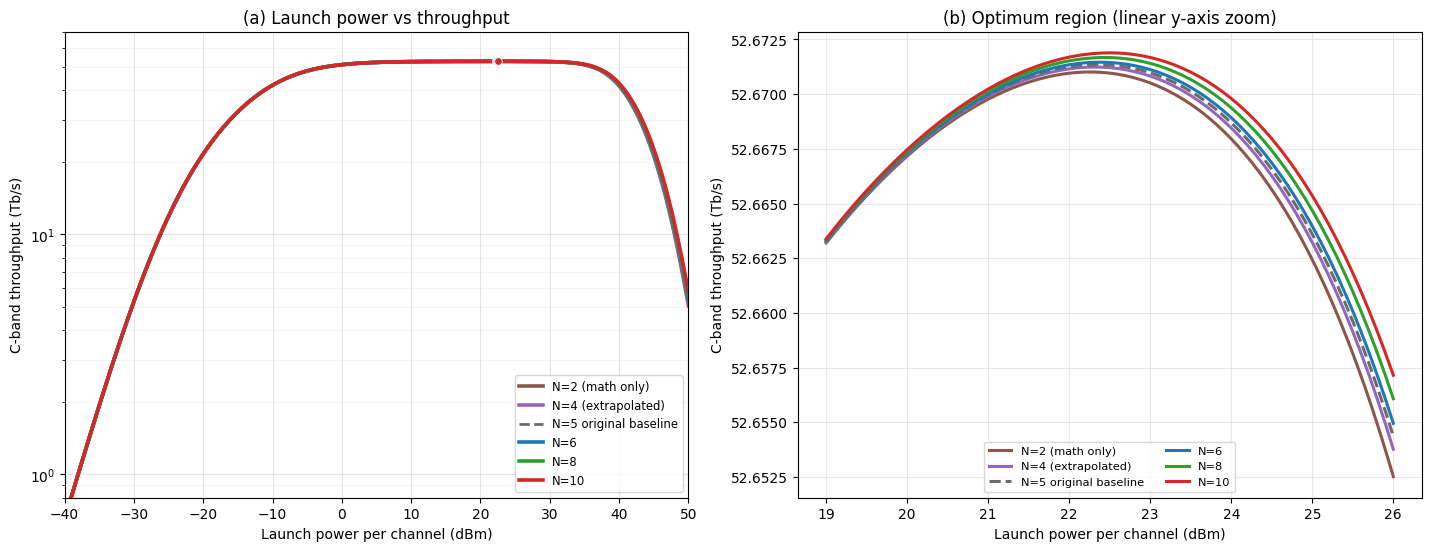

In [4]:
colors = {
    2: "#8c564b",
    4: "#9467bd",
    5: "#6b6b6b",
    6: "#1f77b4",
    8: "#2ca02c",
    10: "#d62728",
}
labels = {
    2: "N=2 (math only)",
    4: "N=4 (extrapolated)",
    5: "N=5 original baseline",
    6: "N=6",
    8: "N=8",
    10: "N=10",
}

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.4), constrained_layout=True)

ax = axes[0]
for n in ALL_TUBE_COUNTS:
    result = results[n]
    style = "--" if n == 5 else "-"
    width = 2.6 if n in REQUESTED_TUBE_COUNTS else 2.0
    ax.plot(
        result["launch_dbm"],
        result["throughput_tbps"],
        color=colors[n],
        ls=style,
        lw=width,
        label=labels[n],
    )
    i = int(result["optimum_index"])
    ax.scatter(
        np.asarray(result["launch_dbm"])[i],
        np.asarray(result["throughput_tbps"])[i],
        s=30,
        color=colors[n],
        edgecolors="white",
        linewidths=0.6,
        zorder=5,
    )
ax.set_yscale("log")
ax.set_xlim(-40, 50)
ax.set_ylim(0.8, 70)
ax.set_xlabel("Launch power per channel (dBm)")
ax.set_ylabel("C-band throughput (Tb/s)")
ax.set_title("(a) Launch power vs throughput")
ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", axis="y", alpha=0.12)
ax.legend(fontsize=8.4, loc="lower right")

ax = axes[1]
launch_zoom = np.asarray(results[5]["launch_dbm"])
mask = (launch_zoom >= 19.0) & (launch_zoom <= 26.0)
for n in ALL_TUBE_COUNTS:
    result = results[n]
    style = "--" if n == 5 else "-"
    ax.plot(
        launch_zoom[mask],
        np.asarray(result["throughput_tbps"])[mask],
        color=colors[n],
        ls=style,
        lw=2.2,
        label=labels[n],
    )
ax.set_xlabel("Launch power per channel (dBm)")
ax.set_ylabel("C-band throughput (Tb/s)")
ax.set_title("(b) Optimum region (linear y-axis zoom)")
ax.grid(True, alpha=0.30)
ax.legend(fontsize=8.2, loc="lower center", ncol=2)

fig.savefig("dnanf_tube_count_power_throughput.png", dpi=220, bbox_inches="tight")
plt.show()


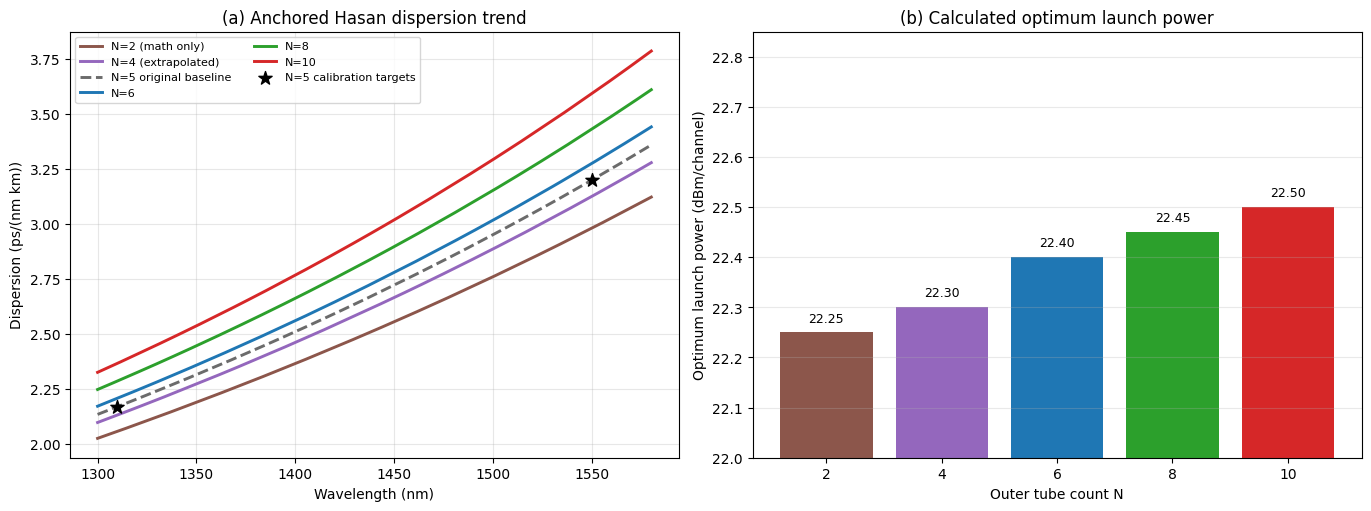

In [5]:
wavelength_nm = np.linspace(1300.0, 1580.0, 500)
requested_summary = summary[summary["tube_count"].isin(REQUESTED_TUBE_COUNTS)]

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0), constrained_layout=True)
ax = axes[0]
for n in ALL_TUBE_COUNTS:
    f1, f2 = anchored_coefficients(n)
    dispersion = chromatic_dispersion_ps_nm_km(wavelength_nm * 1e-9, f1, f2)
    ax.plot(
        wavelength_nm,
        dispersion,
        color=colors[n],
        ls="--" if n == 5 else "-",
        lw=2.1,
        label=labels[n],
    )
ax.scatter([1310, 1550], [2.17, 3.20], marker="*", s=100, color="black", zorder=5,
           label="N=5 calibration targets")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Dispersion (ps/(nm km))")
ax.set_title("(a) Anchored Hasan dispersion trend")
ax.grid(True, alpha=0.30)
ax.legend(fontsize=8.0, ncol=2)

ax = axes[1]
n_values = requested_summary["tube_count"].to_numpy()
p_values = requested_summary["optimum_launch_dbm_ch"].to_numpy()
bars = ax.bar(n_values.astype(str), p_values, color=[colors[int(n)] for n in n_values])
for bar, value in zip(bars, p_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.2f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(p_values.min() - 0.25, p_values.max() + 0.35)
ax.set_xlabel("Outer tube count N")
ax.set_ylabel("Optimum launch power (dBm/channel)")
ax.set_title("(b) Calculated optimum launch power")
ax.grid(True, axis="y", alpha=0.28)

fig.savefig("dnanf_tube_count_dispersion_optimum_power.png", dpi=220, bbox_inches="tight")
plt.show()


## 결과를 어떻게 해석해야 하는가

이 기본 비교에서 tube 개수를 늘리면 Hasan 모델의 (f_2)가 증가하여 C-band 분산이 조금 커지고,
GN 계수 η가 조금 감소합니다. 그 결과 최적 launch power가 약간 증가하지만,
HCF는 이미 γ가 매우 작고 처리량이 TRX SNR/IMI에 의해 제한되므로 **차이는 매우 작게** 나타납니다.

따라서 이 결과만으로 “10-tube가 6-tube보다 우수하다”고 결론 내리면 안 됩니다. 실제 tube-count 설계 비교에서
중요한 것은 다음 값들입니다.

1. full-vector FEM으로 구한 wavelength-dependent confinement loss
2. bend loss와 microbend 민감도
3. HOM loss / fundamental-mode loss 및 모드 결합(IMI)
4. 실제 제작 공차(막 두께, tube 간 gap, nested-tube 위치 편차)
5. tube-count 변화와 함께 바뀌는 outer-tube diameter, 유효 모드 면적, γ

즉, **tube 개수 비교는 물리적으로 의미가 있지만**, tube 개수만 바꾸고 나머지 손실·분산 기준값을 동일하게
재보정하는 현재 Fig. 2 모델만으로는 정밀한 우열 비교가 불가능합니다. 이 Colab의 기본 결과는
“분산 경로만 분리한 민감도 분석”입니다.


In [6]:
# 선택 실행 셀: 각 형상의 FEM 또는 측정 손실[dB/km @1550 nm]이 있으면 여기에 입력하십시오.
# 값이 없는 상태에서 임의의 손실을 넣으면 결과를 물리적 예측으로 해석할 수 없습니다.
#
# measured_or_fem_loss = {
#     2: ...,  # N=2는 폐쇄 ring 형상이 아니므로 일반적으로 제외
#     4: ...,
#     5: 0.075,
#     6: ...,
#     8: ...,
#     10: ...,
# }
# custom_results, custom_summary = run_sweep(measured_or_fem_loss)
# display(custom_summary)


## 참고문헌 및 모델 범위

1. R. Sohanpal *et al.*, “On the Optimum Energy-per-bit Launch Power in Coherent Hollow-core Fibre Transmission Systems,” arXiv:2606.17942 (2026).
2. M. I. Hasan, N. Akhmediev, and W. Chang, “Empirical formulae for hollow-core antiresonant fibers: dispersion and effective mode area,” arXiv:1708.06879 (2017). 특히 tube geometry 식 (1), (R_{\rm eff}) 식 (3), (f_1,f_2) 식 (5)–(7).
3. P. Poggiolini and F. Poletti, “Opportunities and Challenges for Long-Distance Transmission in Hollow-Core Fibres,” *J. Lightwave Technol.* 40(6), 1605–1616 (2022), DOI: 10.1109/JLT.2021.3140114.

**재현성 주의:** 원 논문의 DNANF 손실·분산은 full-vector simulation을 기반으로 하며 모든 tube-count별 FEM 결과는 공개되어 있지 않습니다. 이 노트북은 논문값을 tube-count별 결과 배열로 직접 입력하지 않습니다.
